# Tutorial: **δHBV 1.1p**

---

This notebook demonstrates training and forward simulation with the δHBV 1.1p model developed by [Yalan Song et al. (2025)](https://doi.org/10.22541/essoar.172304428.82707157/v2). A pre-trained model is provided for those who only wish to run the model forward.

For explanation of model structure, methodologies, data, and performance metrics, please refer to Song's publication [below](#publication). If you find this code is useful in your own work, please include the aforementioned citation.

**Note**: If you are new to the dMG framework, we suggest first looking at our [δHBV 1.0 tutorial](./../hydrology/example_dhbv.ipynb).

<br>

### Before Running:
- **Environment**: See [setup.md](./../../docs/setup.md) for ENV setup. dMG must be installed with dependencies + hydrodl2 to run this notebook.

- **Model**: Download pretrained δHBV 1.1p model weights from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/models/dhbv_1_1p_trained.zip). Then update the model config:

    - In [`./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml`](./../conf/config_dhbv_1_1p.yaml), update *trained_model* with your path to the parent directory containing both trained model weights `dhbv_1_1p_ep50.pt` (or *Ep100*) **and** normalization file `normalization_statistics.json`.
    - **Note**: make sure this path includes the last closing forward slash: e.g., `./your/path/to/model/`.

- **Data**: Download the CAMELS data extraction from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/camels/camels_data.zip). Then, updated the data configs:

    - In [`./generic_deltamodel/example/conf/observations/camels_531.yaml`](./../conf/observations/camels_531.yaml) and [`camels_671.yaml`](./../conf/observations/camels_671.yaml), update...
        1. *data_path* with `camels_dataset` path,
        2. *gage_info* with `gage_ids.npy` path,
        3. *subset_path* with `531_subset.txt` path (camels_531 only).

    - The full 671-basin or 531-basin CAMELS datasets can be selected by setting `observations: camels_671` or `camels_531` in the model config, respectively.

- **Hardware**: The NNs used in this model require CUDA support only available with Nvidia GPUs. For those without access, T4 GPUs can be used when running this notebook with dMG on [Google Colab](https://colab.research.google.com/).

<br>

### Publication:

*Yalan Song, Kamlesh Sawadekar, Jonathan M Frame, Ming Pan, Martyn Clark, Wouter J M Knoben, Andrew W Wood, Trupesh Patel, Chaopeng Shen. "Physics-informed, Differentiable Hydrologic  Models for Capturing Unseen Extreme Events." ESS Open Archive (2025). https://doi.org/10.22541/essoar.172304428.82707157/v2.*

<br>

### Issues:
For questions, concerns, bugs, etc., please reach out by posting an [issue](https://github.com/mhpi/generic_deltamodel/issues).

---


## 1. Forward δHBV 1.1p Simulation Mode (no output metrics saved)

After completing training or you have pretrianed models saved, forward δHBV 1.1p with the code block below.

Note:
- The settings defined in the config `./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml` are set to replicate benchmark performance on 531 CAMELS basins.
- The first year (`warm_up` in the config, default is 365 days) of the inference period is used for initializing HBV's internal states (water storages) and is, therefore, excluded from the model's prediction output.

### 1.1 Simulation Settings Demonstration

In [1]:
import sys
sys.path.append('../../') 
from src.dmg import ModelHandler 
from src.dmg.core.utils import import_data_loader, print_config, print_dataset_info, set_randomseed
from example import load_config 
#------------------------------------------#
# Define model settings here.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
#------------------------------------------#

# 1. Load configuration dictionary of model parameters and options.
config = load_config(CONFIG_PATH)
config['mode'] = 'sim'

print_config(config)
# print("Config Keys:", config.keys())
# print("config['multimodel_type']", config['multimodel_type'])
# Set random seed for reproducibility.
set_randomseed(config['seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True) # model key is ['Hbv_1_1p'] 
nn_model = model.model_dict["Hbv_1_1p"].nn_model

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=False, overwrite=False)
print_dataset_info(data_loader.dataset)    


Current Configuration
  Experiment Mode:    sim                 
  Model 1:            Hbv_1_1p            
  Dynamic Params:     ['parBETA', 'parK0', 'parBETAET']

Data Loader
  Data Source:        camels_531          
  Simulation Range :  2009/10/01          2012/09/30          

Experiment Parameters
  Train Epochs:       100                 Batch Size:         100                 
  Start Epoch:        0                   Save Epoch:         5                   
  Loss Fn:            NseBatchLoss        
  Optimizer:          Adadelta            LR Scheduler:       None                

Machine
  Device:             cuda:0              
  Dtype:              torch.float32       


Dataset Inputs
Dataset key    Shape               Description
------------------------------------------------------------
x_phy          (1096, 531, 3)       # [time, basin, forcing_features]
c_phy          (531, 0)             # [basin, attr_features] (no physical attributes here)
x_nn           (1096

In [2]:
import numpy as np
import json
# # Gage settings
gage_ids = np.load(config["observations"]["gage_info"], allow_pickle=True)
subset_file = config["observations"]["subset_path"]
GAGE_NAME_PATH = "./predownloaded/camels_name.txt"

with open(subset_file, "r") as f:
    content = f.read().strip()
gage_ids_subset = json.loads(content) if content.startswith("[") else np.loadtxt(subset_file, dtype=int).tolist()  

# 1. Predictions and timesteps
GAGE_ID = 9035900 # 2350900 

if config['observations']['name'] == 'camels_671':
    basin_idx = list(gage_ids).index(GAGE_ID) if GAGE_ID in gage_ids else None
    basin_pool = list(gage_ids)
elif config['observations']['name'] == 'camels_531':
    basin_idx = list(gage_ids_subset).index(GAGE_ID) if GAGE_ID in gage_ids_subset else None
    basin_pool = list(gage_ids_subset)

### 1.2 Simulation with Daymet Forcings Only

In [3]:
wantorun = False # set to true if you want the simulation result with only daymet forcings

import pandas as pd
import torch
from tempfunctions import *
from src.dmg.core.post import plot_hydrograph
from src.dmg.core.utils import Dates
if wantorun:
    output = model(
        data_loader.dataset,
        eval=True,
    )

    # prediction can be numpy
    pred = output['Hbv_1_1p']['streamflow']
    timesteps = Dates(config['sim'], config['model']['rho']).batch_daily_time_range
    warm_up = config['model']['phy']['warm_up']
    timesteps = timesteps[warm_up:]
    streamflow_pred_basin = pred[:, basin_idx].squeeze()
    if torch.is_tensor(streamflow_pred_basin):
        streamflow_pred_basin = streamflow_pred_basin.detach().cpu().numpy()

    # keep obs as torch tensor so plot_hydrograph does not zero it out 
    obs_basin = data_loader.dataset["target"][:, basin_idx].squeeze()
    if not torch.is_tensor(obs_basin):
        obs_basin = torch.as_tensor(obs_basin)

    # 2. Plot
    RESAMPLE = 'D'
    obs_basin = obs_basin[warm_up:]
    gage_name = obtain_gage_name(GAGE_NAME_PATH, GAGE_ID)

    plot_hydrograph(
        timesteps,
        streamflow_pred_basin,
        obs=obs_basin,
        resample=RESAMPLE,
        title=f"Hydrograph for Gage ID {GAGE_ID} ({gage_name})",
        ylabel='Streamflow (mm/day)',
    )

### 1.3 GEFS Simulation with warm start


=== Running forecast for basin 1073000 ===
save start
save for simulation
save stop
last sim_pre_GEFS value: 0.19342011
first Q_next value: 0.1959271

Dataset Inputs
Dataset key    Shape               Description
------------------------------------------------------------
x_phy          (1096, 531, 3)       # [time, basin, forcing_features]
c_phy          (531, 0)             # [basin, attr_features] (no physical attributes here)
x_nn           (1096, 531, 3)       # [time, basin, nn_forcing_features]
c_nn           (531, 35)            # [basin, nn_attr_features]
xc_nn_norm     (1096, 531, 38)      # [time, basin, combined_features]
target         (1096, 531, 1)       # [time, basin, 1] observed streamflow

Sample of target tensor (first 5 timesteps, first basin):
tensor([1.0365, 0.8744, 0.7507, 2.0175, 2.3928], device='cuda:0')
Difference between continuous first forecast value and restart first forecast value:
 0.010467485
Saved top figure to: ./output/camels_531/plots/3GEFS/GEFS_

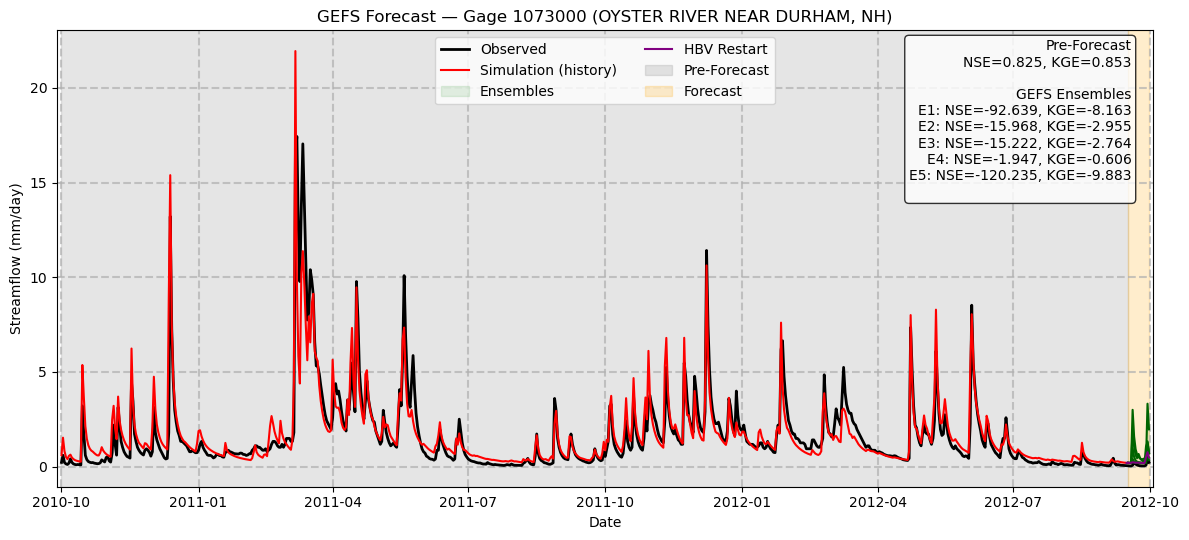

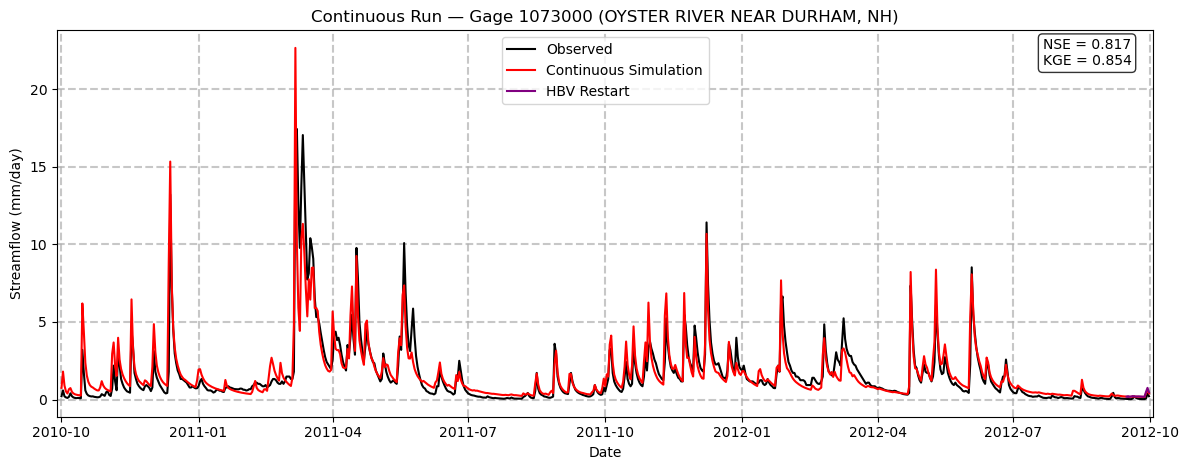

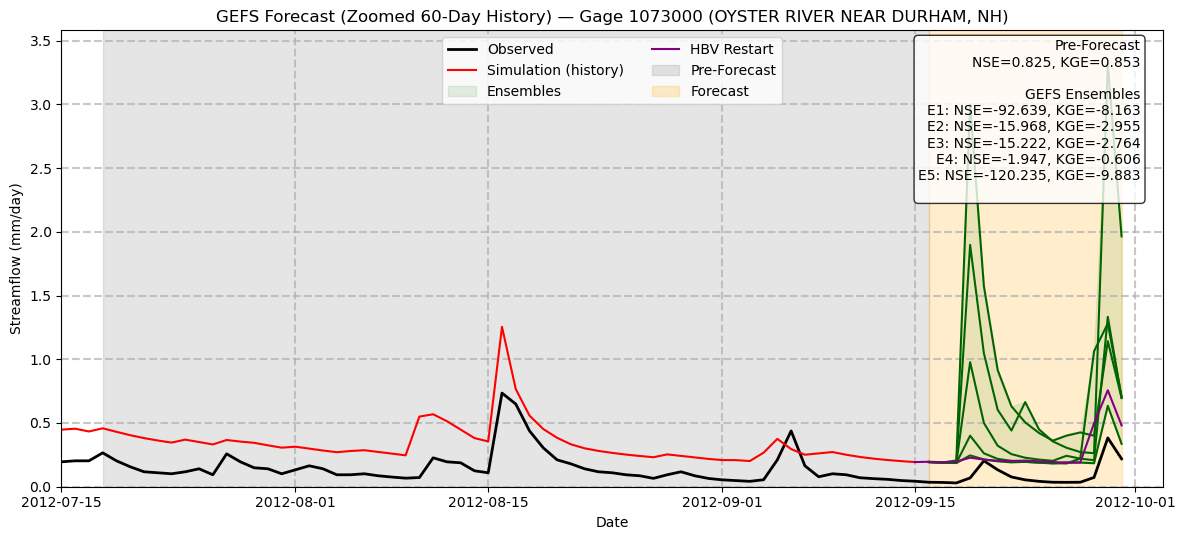

Saved plot for basin 1073000 → ./output/camels_531/plots/3GEFS/GEFS_1073000


In [4]:
import os
import numpy as np
import pandas as pd
import torch 
from src.dmg.core.utils import Dates  
import importlib
import tempfunctions
importlib.reload(tempfunctions)
from tempfunctions import *

# ---------------- Path settings ---------------- #
GEFS_DIR       = "/u/st/dr/awwood/aw-ciroh-proj/projects/dl_da/daymet-gefs-camels-gII"
STATE_PATH     = f"{config['sim_dir']}simulation_gefs/save_states_restart/model_states.pt" # where the stopped states are saved:nn+hbv

# ---------------- Simulation settings ---------------- #
PRED_DATE      = pd.to_datetime("2012-09-16")
FORECAST       = 15
N_ENSEMBLES    = 5
WARMUP         = 365  # this is to change it differ from the config warmup, if you want to, otherwise it is the same
device         = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

# ---------------- Post/Pre-processing settings ---------------- #
WINDOW         = 30 # pre-processing on correcting window (in days)
PRE            = 'scalar'  # or 'cdf'
POST           = True
 
# ---------------- Basin(s) selection ---------------- #
# selected_basins = [
selected_basins = selectbasins()  # [9035900] # 7362100, 2350900 
selected_basins = selected_basins[:1]
sidx, eidx, timesteps, history_len = startid_endid(config, WARMUP, PRED_DATE, FORECAST)

# ---------------- Loop over selected basins ---------------- #
for GAGE_ID in selected_basins:
    print(f"\n=== Running forecast for basin {GAGE_ID} ===")
    basin_idx = basin_pool.index(GAGE_ID) 
    name = list(model.model_dict.keys())[0]
     
    # ----------- Run then stop at sidx------------- #  
    ###################################################### 
    sim_pre_GEFS = run_segment(# 716 
        model=model,
        dataset=data_loader.dataset,
        basin_idx=basin_idx,
        device=device,
        name=name,
        start_idx=None,
        end_idx=sidx,
        warm_up=WARMUP,
        cache_states=True,
        warm_up_states=True,
    )
    # save states to external file
    model.verbose = False    
    print("save start")
    model.save_states() # nn: <class 'tuple'>, phy:tuple of 5 torch.Size([1, 16]) --> 5*[1, 16],  (sp, mw, sm, suz, slz) 
    ######################################################
    print("save stop")
    
    # ---------------- Restart rest (keep daymet forcings) ---------------- # 
    ######################################################
    Q_next = run_segment(
        model=model,
        dataset=data_loader.dataset,
        basin_idx=basin_idx,
        device=device,
        name=name,
        start_idx=sidx,
        end_idx=None,
        warm_up=0,
        cache_states=True,
        warm_up_states=True,
        state_path=STATE_PATH,
    )
    print("last sim_pre_GEFS value:", sim_pre_GEFS[-1])
    print("first Q_next value:", Q_next[0])
    ######################################################
      
    
    # ---------------- Restart rest (using GEFS forcings) ---------------- #
    ######################################################
    ens_preds = run_warm_forecasts_restart( 
        model=model,
        data_loader=data_loader,
        state_path=STATE_PATH,
        gage_id=GAGE_ID,
        basin_idx=basin_idx,
        start_date=PRED_DATE,
        horizon=FORECAST,
        N_ENSEMBLES=N_ENSEMBLES,
        GEFS_DIR=GEFS_DIR,
        timesteps=timesteps,
        WINDOW=WINDOW,
        CORRECTION=PRE,
        device=device,
        verbose=model.verbose,
    )
    
    if POST:
        ens_preds = post_processing(sim_pre_GEFS, ens_preds) # post-processing
    ######################################################
    
    
    # ---------------- Continuous Simulation ---------------- #
    ######################################################
    # 1. RE-Load a model
    CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml' 
    config = load_config(CONFIG_PATH)
    config['mode'] = 'sim'
    set_randomseed(config['seed'])
    model = ModelHandler(config, verbose=True) # model key is ['Hbv_1_1p'] 
    nn_model = model.model_dict["Hbv_1_1p"].nn_model

    # 2. Load and initialize a dataset dictionary of NN and HBV model inputs.
    data_loader_cls = import_data_loader(config['data_loader'])
    data_loader = data_loader_cls(config, test_split=False, overwrite=False)
    print_dataset_info(data_loader.dataset)  
    full_dict = {
        "xc_nn_norm":data_loader.dataset["xc_nn_norm"][:, basin_idx:basin_idx+1, :].clone(),  
        "x_phy":data_loader.dataset["x_phy"][:, basin_idx:basin_idx+1, :].clone()
    } 

    # 3. Run a continues run without restart 
    Q_all_np = run_segment( #(731,)
        model=model,
        dataset=data_loader.dataset,
        basin_idx=basin_idx,
        device=device,
        name=name,
        start_idx=None,
        end_idx=None,
        warm_up=WARMUP,
        cache_states=False,
        warm_up_states=True,
    ) 
    Qf_cont  = Q_all_np[sidx - WARMUP:sidx - WARMUP + FORECAST]  # 15  
    print("Difference between continuous first forecast value and restart first forecast value:", Q_next[0] - Qf_cont[0])
    ###################################################################
    
    
    # ---------------- Plotting ---------------- # 
    # create a figure save path 
    save_dir = os.path.join(f"{config['plot_dir']}", f"3GEFS/GEFS_{GAGE_ID}")

    # double-check the respective dismension that will be displayed
    assert len(sim_pre_GEFS) == history_len, \
        f"Expected history_len={history_len}, but got len(sim_pre_GEFS)={len(sim_pre_GEFS)}"
    
    assert len(Q_all_np) + WARMUP - FORECAST == sidx, (
        f"[INDEX MISMATCH ERROR]\n"
        f"len(Q_all_np)={len(Q_all_np)}, WARMUP={WARMUP}, FORECAST={FORECAST}\n"
        f"Computed: {len(Q_all_np)} + {WARMUP} - {FORECAST} = {len(Q_all_np) + WARMUP - FORECAST}\n"
        f"Expected SIDX={sidx}"
    )
    
    # plot
    plot_forecast_separate(
        GAGE_NAME_PATH=GAGE_NAME_PATH,
        gage_id=GAGE_ID,
        start_date=PRED_DATE,
        obs=data_loader.dataset["target"][sidx - history_len : eidx, basin_idx, 0].detach().cpu().numpy(),
        sim=sim_pre_GEFS,
        ens_preds=ens_preds,
        history_len=history_len,
        Q_all_np=Q_all_np,
        sidx=sidx,
        FORECAST=FORECAST,
        WARMUPTIME=WARMUP,
        det_pred=Q_next,
        save_dir=save_dir,
        file_prefix=f"GEFS_{GAGE_ID}_{PRE}_w{WINDOW}_p{POST}",
    )